# Breast Cancer Detection and Prevention Using Machine Learning

This notebook reproduces the paper workflow with a practical, executable pipeline: data loading, preprocessing, feature selection (low variance, univariate selection, RFE), model training (RF, DT, KNN, LR, SVC, Linear SVC), and evaluation.

Paper reference: Khalid et al., Diagnostics 2023, 13, 3113.

## 1. Imports and Reproducibility

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')

## 2. Load Dataset (Kaggle CSV if available, fallback to sklearn)

Expected Kaggle filename: `data.csv` in the same folder as this notebook.

In [2]:
def load_paper_style_dataset(csv_path='data.csv'):
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f'Loaded Kaggle-style dataset from: {csv_path}')
        return df

    data = load_breast_cancer(as_frame=True)
    X = data.frame.drop(columns=['target']).copy()
    X.columns = [c.replace(' ', '_').replace('(', '').replace(')', '') for c in X.columns]

    y = data.frame['target'].map({0: 'M', 1: 'B'})

    df = pd.DataFrame({'id': np.arange(100000, 100000 + len(X)), 'diagnosis': y})
    df = pd.concat([df, X], axis=1)
    df['Unnamed: 32'] = np.nan

    print('Kaggle CSV not found. Loaded sklearn breast cancer dataset as fallback.')
    return df

df = load_paper_style_dataset('data.csv')
print('Shape:', df.shape)
df.head()

Loaded Kaggle-style dataset from: data.csv
Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
print(df.info())
print('\nDiagnosis counts:')
print(df['diagnosis'].value_counts())

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_cols].describe().T.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.00000,869218.00000,906024.00000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.98100,11.70000,13.37000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.71000,16.17000,18.84000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.79000,75.17000,86.24000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.50000,420.30000,551.10000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.05263,0.08637,0.09587,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.01938,0.06492,0.09263,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.00000,0.02956,0.06154,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.00000,0.02031,0.03350,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.10600,0.16190,0.17920,1.957000e-01,3.040000e-01


## 3. Cleaning and Outlier Handling

Paper-aligned strategy: remove duplicates, handle nulls, and optionally reduce benign outliers only.

In [4]:
df = df.drop_duplicates().copy()

if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

for col in df.columns:
    if df[col].dtype.kind in 'biufc':
        df[col] = df[col].fillna(df[col].median())

def remove_benign_outliers_iqr(frame, label_col='diagnosis', benign_label='B', iqr_scale=1.5):
    work = frame.copy()
    benign = work[work[label_col] == benign_label].copy()
    non_benign = work[work[label_col] != benign_label].copy()

    num_cols = benign.select_dtypes(include=np.number).columns.tolist()
    num_cols = [c for c in num_cols if c != 'id']

    mask = pd.Series(True, index=benign.index)
    for col in num_cols:
        q1, q3 = benign[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - iqr_scale * iqr
        upper = q3 + iqr_scale * iqr
        mask &= benign[col].between(lower, upper)

    benign_clean = benign[mask]
    return pd.concat([benign_clean, non_benign], axis=0).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

df_clean = remove_benign_outliers_iqr(df)
print('Original shape:', df.shape)
print('After benign-outlier handling:', df_clean.shape)
df_clean['diagnosis'].value_counts()

Original shape: (569, 32)
After benign-outlier handling: (466, 32)


diagnosis
B    254
M    212
Name: count, dtype: int64

## 4. Feature / Label Split and Standardization

In [5]:
y = df_clean['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

drop_cols = [c for c in ['diagnosis', 'id'] if c in df_clean.columns]
X = df_clean.drop(columns=drop_cols)

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
X = X[numeric_cols].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test shape:', X_test_scaled.shape)

Train shape: (326, 30)
Test shape: (140, 30)


## 5. Three-Stage Feature Selection

1) Low-variance filter  2) Univariate selection  3) Recursive feature elimination (RFE).

In [6]:
# Stage 1: Remove very low-variance features
vt = VarianceThreshold(threshold=0.0)
X_train_v = vt.fit_transform(X_train_scaled)
X_test_v = vt.transform(X_test_scaled)

stage1_features = X.columns[vt.get_support()]

# Stage 2: Univariate feature selection
k_best = min(20, X_train_v.shape[1])
skb = SelectKBest(score_func=f_classif, k=k_best)
X_train_k = skb.fit_transform(X_train_v, y_train)
X_test_k = skb.transform(X_test_v)

stage2_features = stage1_features[skb.get_support()]

# Stage 3: RFE
n_rfe = min(10, X_train_k.shape[1])
rfe = RFE(
    estimator=LogisticRegression(max_iter=5000, solver='liblinear'),
    n_features_to_select=n_rfe
)
X_train_fs = rfe.fit_transform(X_train_k, y_train)
X_test_fs = rfe.transform(X_test_k)

selected_features = stage2_features[rfe.get_support()]

print('Features after stage 1:', X_train_v.shape[1])
print('Features after stage 2:', X_train_k.shape[1])
print('Features after stage 3:', X_train_fs.shape[1])
print('Selected features:')
print(list(selected_features))

Features after stage 1: 30
Features after stage 2: 20
Features after stage 3: 10
Selected features:
['concavity_mean', 'concave points_mean', 'radius_se', 'perimeter_se', 'compactness_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concavity_worst']


## 6. Train the Six Classifiers

In [7]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'SVC': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
    'Linear SVC': LinearSVC(max_iter=10000, random_state=RANDOM_STATE)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_fs, y_train)
    preds = model.predict(X_test_fs)

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    }
    results.append(row)
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1
0,SVC,0.992857,0.984615,1.000000,0.992248
1,Logistic Regression,0.992857,0.984615,1.000000,0.992248
2,KNN,0.985714,0.969697,1.000000,0.984615
3,Random Forest,0.985714,0.984375,0.984375,0.984375
4,Linear SVC,0.985714,0.969697,1.000000,0.984615
5,Decision Tree,0.957143,0.939394,0.968750,0.953846


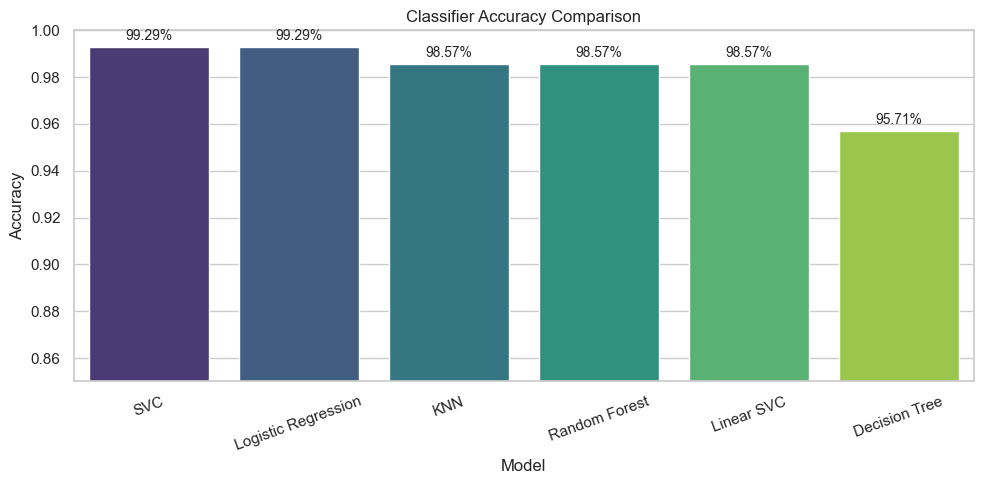

Best model: SVC
Best accuracy: 99.29%


In [8]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=results_df, x='Model', y='Accuracy', palette='viridis')
plt.xticks(rotation=20)
plt.ylim(0.85, 1.0)
plt.title('Classifier Accuracy Comparison')
plt.ylabel('Accuracy')

for i, val in enumerate(results_df['Accuracy'].values):
    ax.text(i, val + 0.003, f'{val*100:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print('Best model:', results_df.loc[0, 'Model'])
print('Best accuracy:', f"{results_df.loc[0, 'Accuracy']*100:.2f}%")

## 7. Confusion Matrix (Best Model)

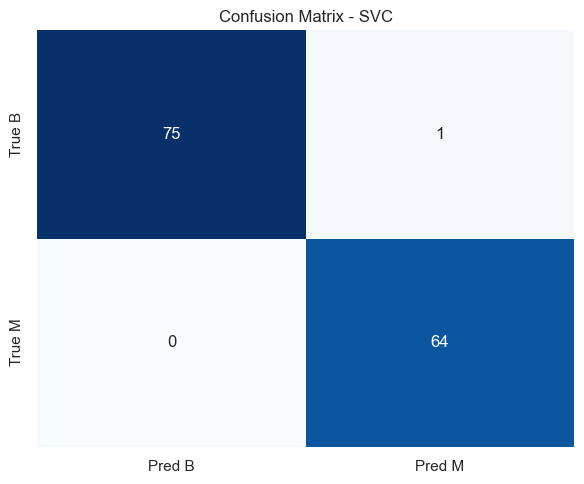

TP: 64, FP: 1, FN: 0, TN: 75

Classification report:
               precision    recall  f1-score   support

   Benign (B)       1.00      0.99      0.99        76
Malignant (M)       0.98      1.00      0.99        64

     accuracy                           0.99       140
    macro avg       0.99      0.99      0.99       140
 weighted avg       0.99      0.99      0.99       140



In [9]:
best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]
best_preds = best_model.predict(X_test_fs)

cm = confusion_matrix(y_test, best_preds)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred B', 'Pred M'], yticklabels=['True B', 'True M'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

print(f'TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}')
print('\nClassification report:')
print(classification_report(y_test, best_preds, target_names=['Benign (B)', 'Malignant (M)']))

## 8. EDA Visuals Similar to Paper

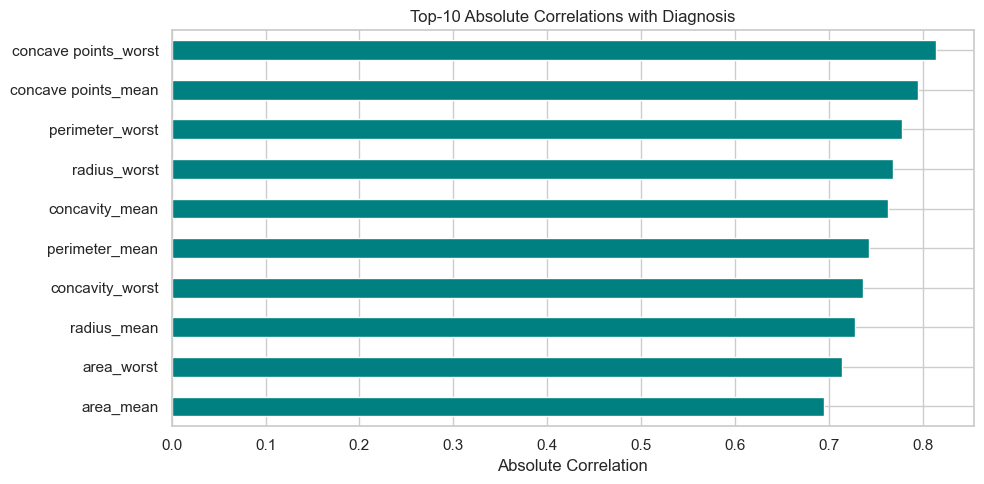

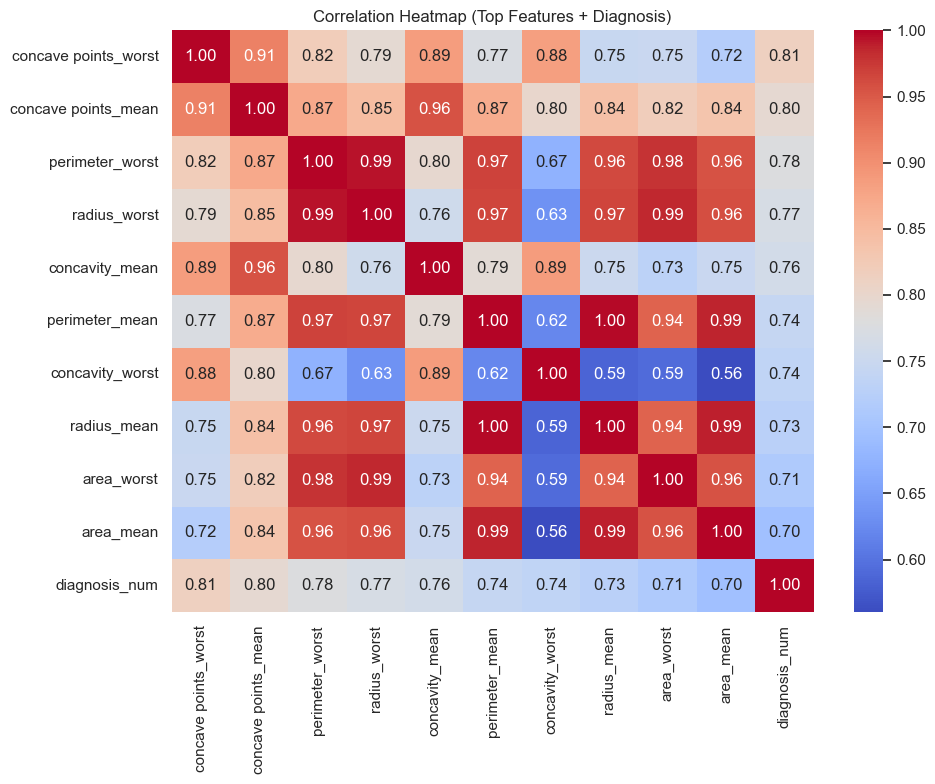

In [10]:
eda_df = df_clean.copy()
num_eda_cols = [c for c in eda_df.select_dtypes(include=np.number).columns if c != 'id']

# Top-10 correlations with diagnosis
corr_df = eda_df[num_eda_cols].copy()
corr_df['diagnosis_num'] = eda_df['diagnosis'].map({'M': 1, 'B': 0})
corr_series = corr_df.corr()['diagnosis_num'].drop('diagnosis_num').abs().sort_values(ascending=False)
top10 = corr_series.head(10).index.tolist()

plt.figure(figsize=(10, 5))
corr_series.head(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top-10 Absolute Correlations with Diagnosis')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df[top10 + ['diagnosis_num']].corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap (Top Features + Diagnosis)')
plt.tight_layout()
plt.show()

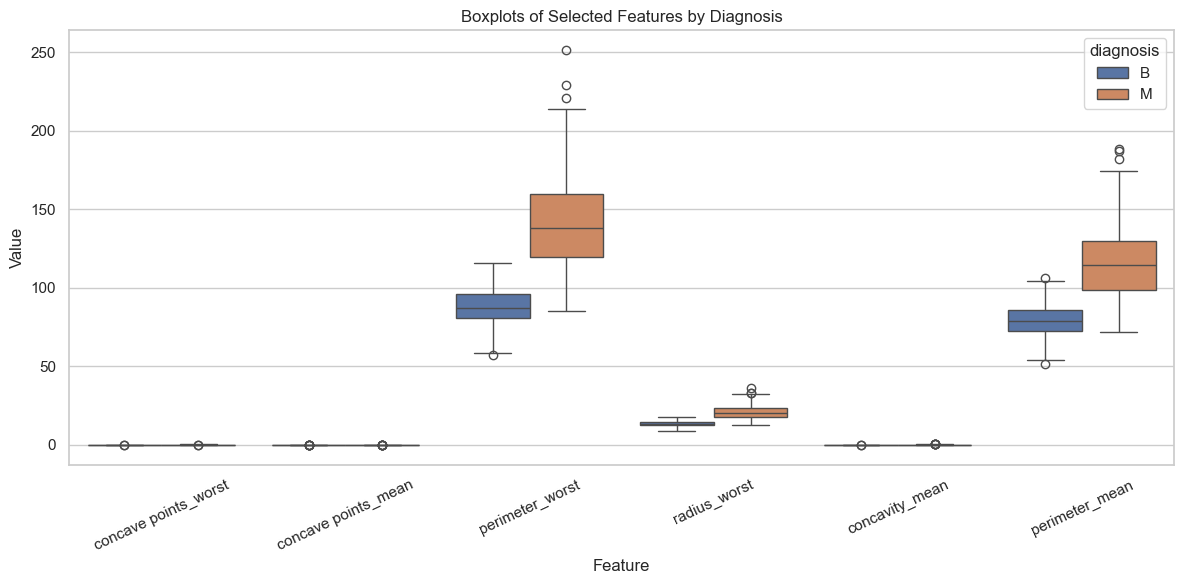

In [11]:
plot_cols = top10[:6]
melted = eda_df[['diagnosis'] + plot_cols].melt(id_vars='diagnosis', var_name='Feature', value_name='Value')

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted, x='Feature', y='Value', hue='diagnosis')
plt.xticks(rotation=25)
plt.title('Boxplots of Selected Features by Diagnosis')
plt.tight_layout()
plt.show()

## 9. K-Fold Cross-Validation (Robustness Check)

In [12]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, np.vstack([X_train_fs, X_test_fs]), np.hstack([y_train, y_test]), cv=cv, scoring='accuracy')
    cv_results.append({
        'Model': name,
        'CV_Mean_Accuracy': scores.mean(),
        'CV_Std': scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values('CV_Mean_Accuracy', ascending=False).reset_index(drop=True)
cv_df

,Model,CV_Mean_Accuracy,CV_Std
0,Logistic Regression,0.982840,0.023029
1,SVC,0.982794,0.023210
2,Linear SVC,0.980712,0.022317
3,KNN,0.978492,0.019240
4,Random Forest,0.974191,0.021076
5,Decision Tree,0.957077,0.025258
